# SR/VR one-file data check

Run one skimmed DoubleMuon data ROOT file through the topology-specific 2mu2e/4mu SR and VR test channels. LJ isolation and cosmic-veto cuts are intentionally omitted for the ABCD scan.

In [1]:
import sys
import os
import importlib

from coffea import processor
import coffea.util
import matplotlib.pyplot as plt
import pandas as pd

sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import llpnanoaodschema, scaleout, sidm_processor, utilities

importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)

utilities.set_plot_style()
%matplotlib inline


In [2]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=False,
)

channels = [
    "test_SR_2mu2e",
    "test_VR_2mu2e",
    "test_SR_4mu",
    "test_VR_4mu",
]
iso_2d_histogram_names = ["mulj_egmlj_iso", "mulj_mulj_iso"]
cut_1d_histogram_names = [
    "abcd_2mu2e_invmass",
    "abcd_2mu2e_absdphi",
    "abcd_4mu_invmass",
    "abcd_4mu_absdphi",
]
iso_3d_histogram_names = [
    "abcd_2mu2e_iso_invmass",
    "abcd_2mu2e_iso_absdphi",
    "abcd_4mu_iso_invmass",
    "abcd_4mu_iso_absdphi",
]
histogram_names = iso_2d_histogram_names + cut_1d_histogram_names + iso_3d_histogram_names

p = sidm_processor.SidmProcessor(
    channels,
    ["abcd_iso_base"],
    unweighted_hist=False,
)


In [3]:
sample = "DoubleMuon_2018C"
fileset = utilities.make_fileset(
    [sample],
    "llpNanoAOD_v2",
    max_files=10,
    location_cfg="data_skimmed.yaml",
)

for sample, sample_fileset in fileset.items():
    print(sample)
    for root_file in sample_fileset["files"]:
        print(f"  {root_file}")


DoubleMuon_2018C
  root://xcache//store/group/lpcmetx/SIDM/Data/2018data/Skims/Run2018C_15Feb2022_UL2018/skimmed_output_1.root
  root://xcache//store/group/lpcmetx/SIDM/Data/2018data/Skims/Run2018C_15Feb2022_UL2018/skimmed_output_10.root
  root://xcache//store/group/lpcmetx/SIDM/Data/2018data/Skims/Run2018C_15Feb2022_UL2018/skimmed_output_100.root
  root://xcache//store/group/lpcmetx/SIDM/Data/2018data/Skims/Run2018C_15Feb2022_UL2018/skimmed_output_101.root
  root://xcache//store/group/lpcmetx/SIDM/Data/2018data/Skims/Run2018C_15Feb2022_UL2018/skimmed_output_102.root
  root://xcache//store/group/lpcmetx/SIDM/Data/2018data/Skims/Run2018C_15Feb2022_UL2018/skimmed_output_103.root
  root://xcache//store/group/lpcmetx/SIDM/Data/2018data/Skims/Run2018C_15Feb2022_UL2018/skimmed_output_104.root
  root://xcache//store/group/lpcmetx/SIDM/Data/2018data/Skims/Run2018C_15Feb2022_UL2018/skimmed_output_105.root
  root://xcache//store/group/lpcmetx/SIDM/Data/2018data/Skims/Run2018C_15Feb2022_UL2018/sk

In [4]:
output_data = runner.run(
    fileset,
    treename="Events",
    processor_instance=p,
)

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

Warning: weight not found in this sample. Skipping.

...

Warning: cannot fill counter Gen As to muons. Skipping.

Warning: cannot fill counter Gen As to electrons. Skipping.

Warning: cannot fill counter Matched gen As to muons. Skipping.

Warning: cannot fill counter Matched gen As to electrons. Skipping.

DoubleMuon_2018C is data. Not scaling histograms or cutflows.


In [5]:
rows = []
sample_output = output_data["out"][sample]
sample_hists = sample_output["hists"]
assert set(channels).issubset(set(sample_hists[histogram_names[0]].axes[0])), "Missing channel axis entries"

for channel in channels:
    final_cut = list(sample_output["cutflow"][channel].rows.values())[-1]
    for histogram_name in histogram_names:
        histogram = sample_hists[histogram_name][{"channel": channel}]
        rows.append({
            "sample": sample,
            "channel": channel,
            "final_raw_events": int(final_cut["raw"]),
            "histogram": histogram_name,
            "yield": float(histogram.values().sum()),
        })

summary = pd.DataFrame(rows)
summary

,sample,channel,final_raw_events,histogram,yield
0,DoubleMuon_2018C,test_SR_2mu2e,1,mulj_egmlj_iso,1.0
1,DoubleMuon_2018C,test_SR_2mu2e,1,mulj_mulj_iso,0.0
2,DoubleMuon_2018C,test_SR_2mu2e,1,abcd_2mu2e_invmass,1.0
3,DoubleMuon_2018C,test_SR_2mu2e,1,abcd_2mu2e_absdphi,1.0
4,DoubleMuon_2018C,test_SR_2mu2e,1,abcd_4mu_invmass,0.0
5,DoubleMuon_2018C,test_SR_2mu2e,1,abcd_4mu_absdphi,0.0
6,DoubleMuon_2018C,test_SR_2mu2e,1,abcd_2mu2e_iso_invmass,1.0
7,DoubleMuon_2018C,test_SR_2mu2e,1,abcd_2mu2e_iso_absdphi,1.0
8,DoubleMuon_2018C,test_SR_2mu2e,1,abcd_4mu_iso_invmass,0.0
9,DoubleMuon_2018C,test_SR_2mu2e,1,abcd_4mu_iso_absdphi,0.0


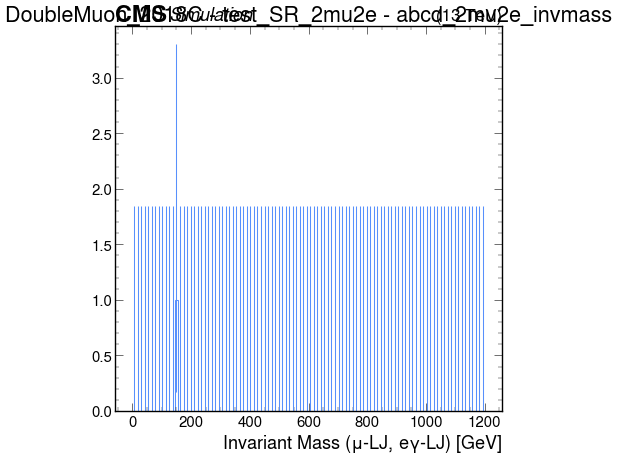

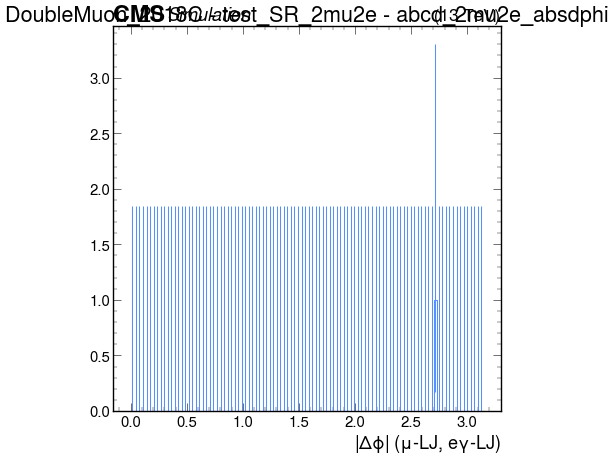

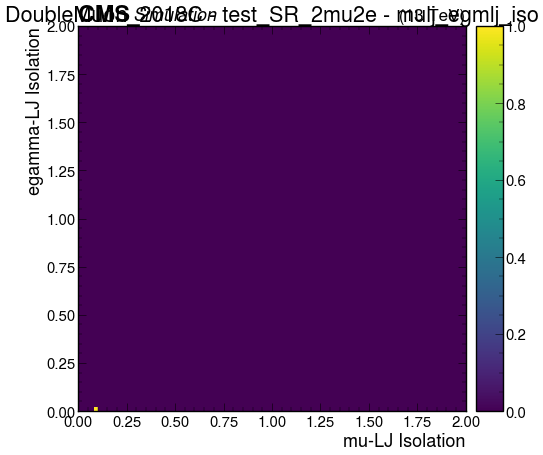

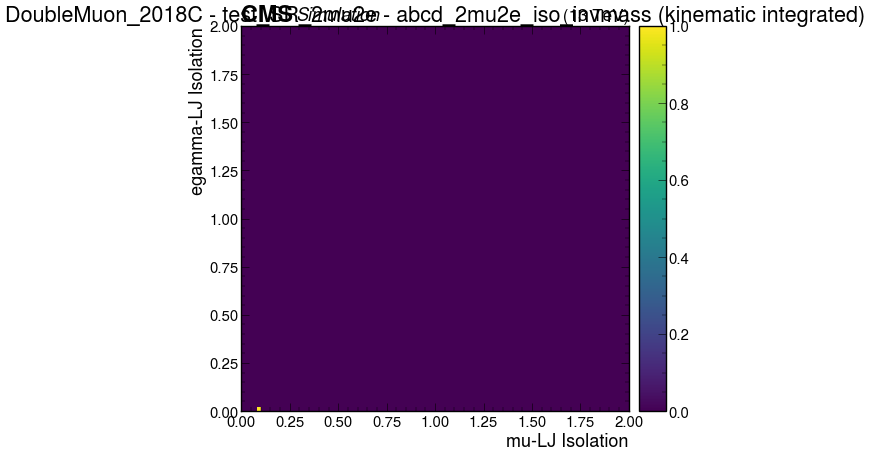

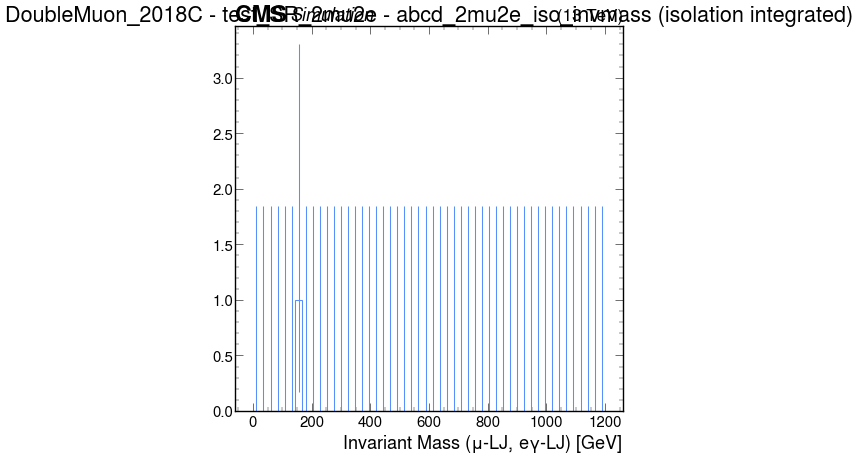

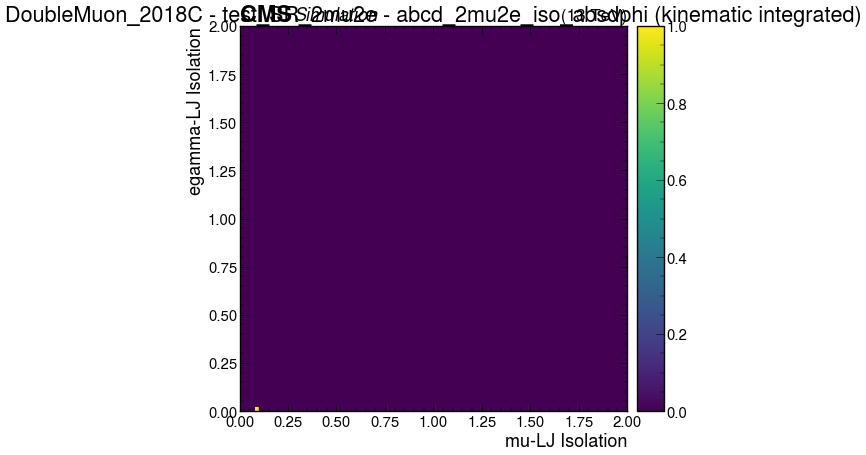

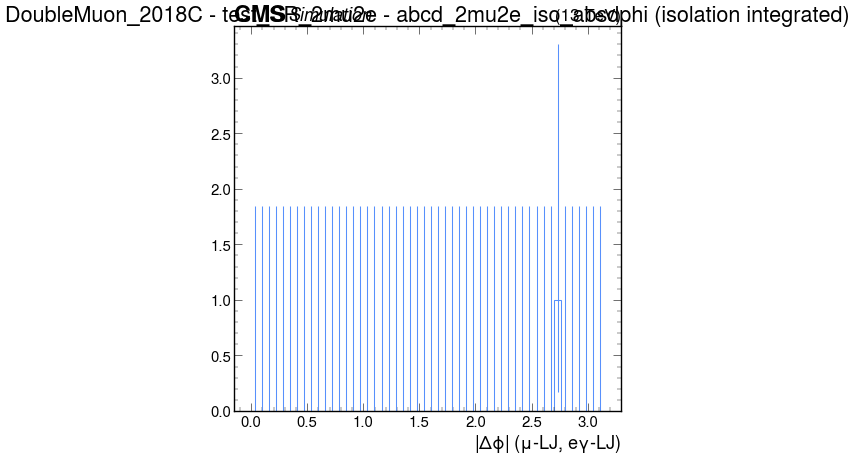

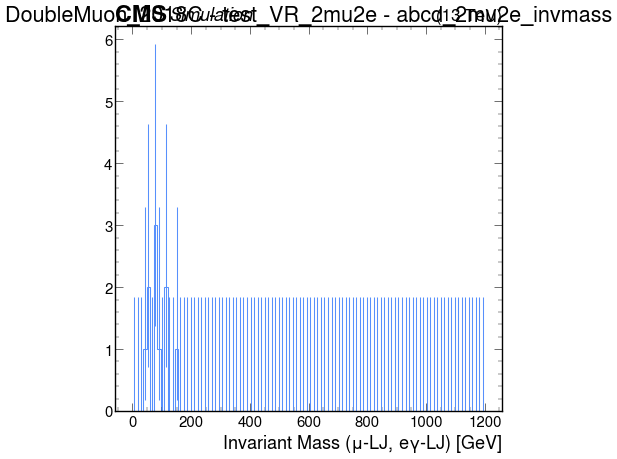

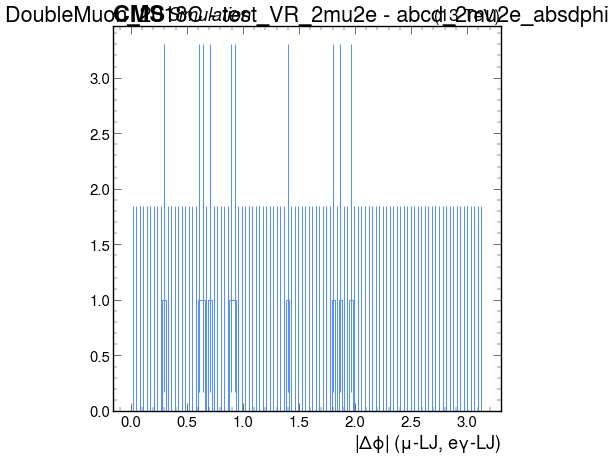

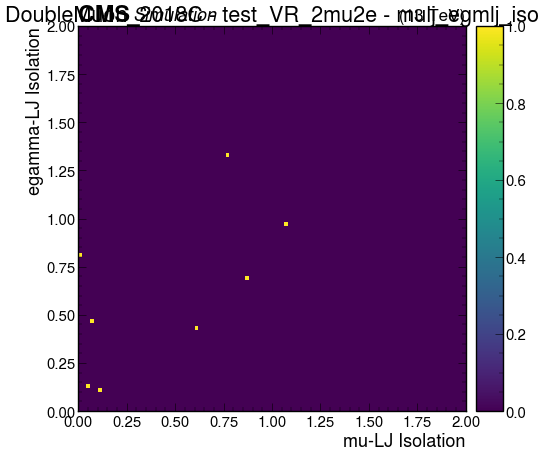

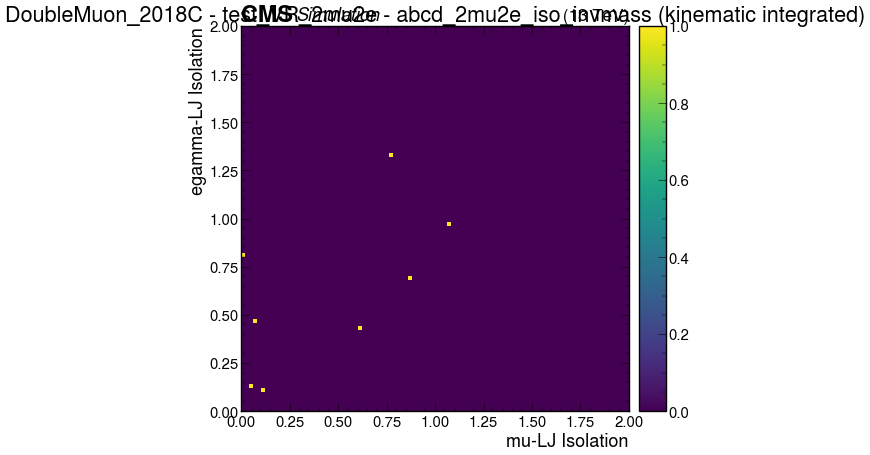

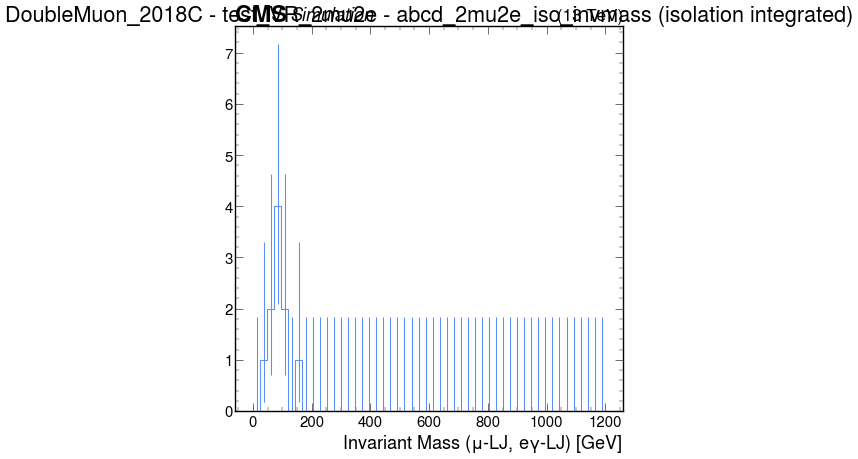

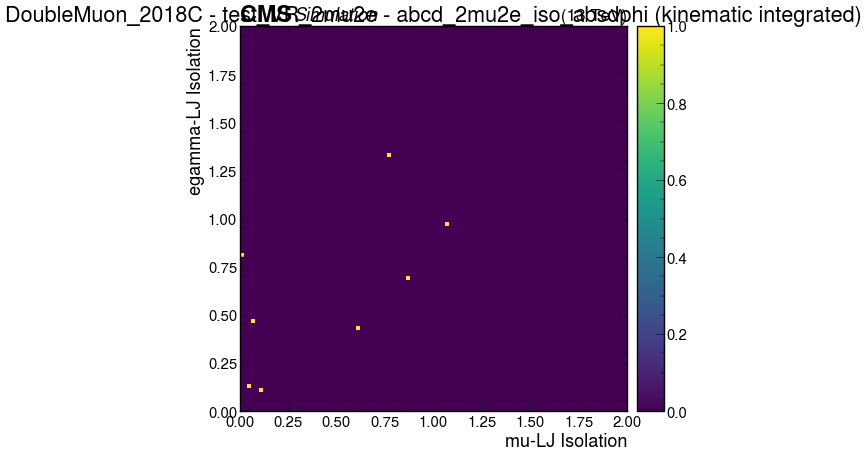

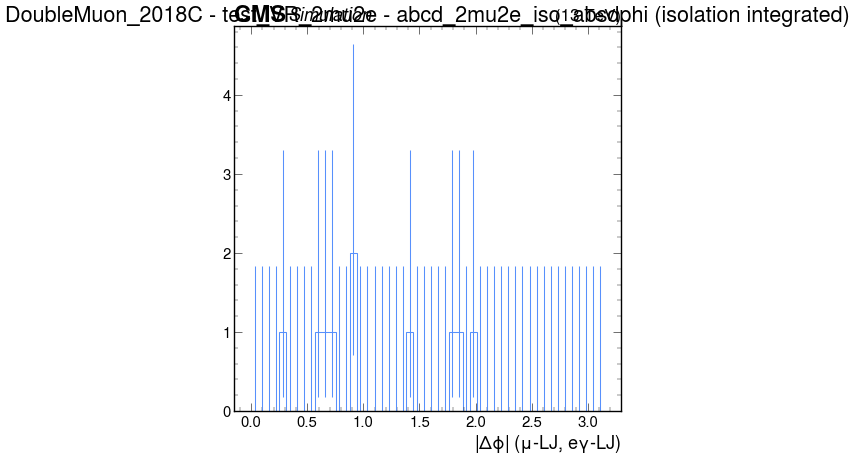

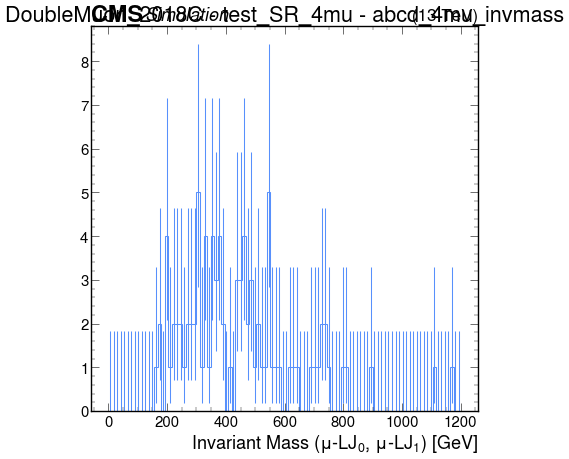

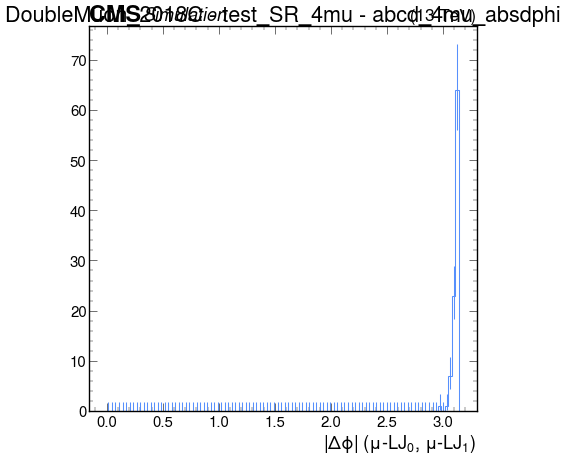

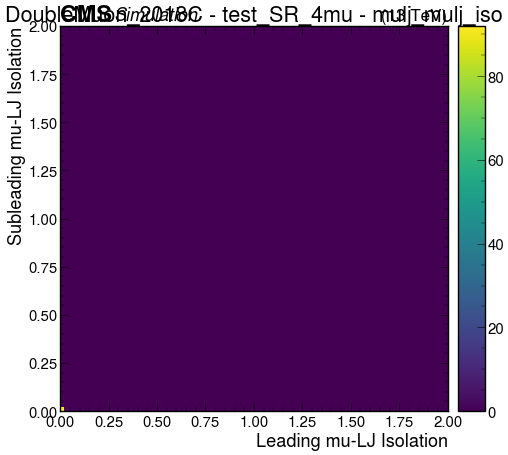

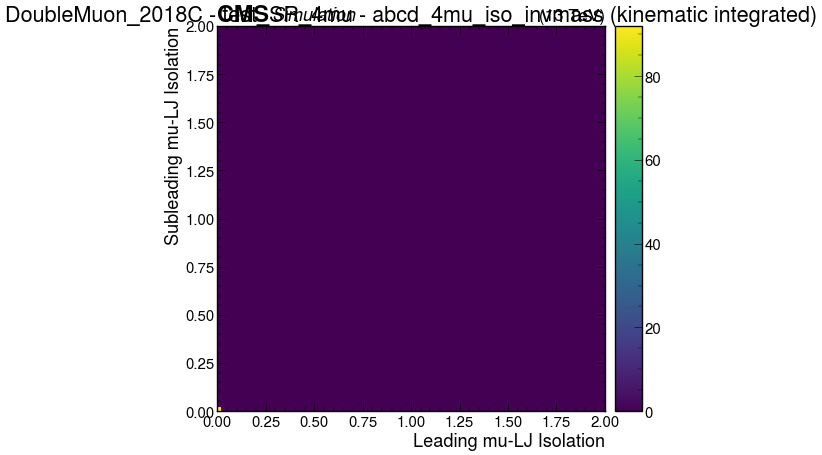

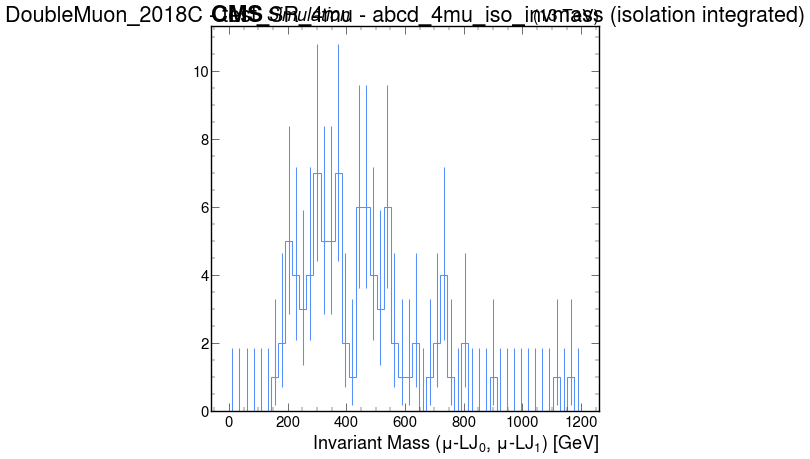

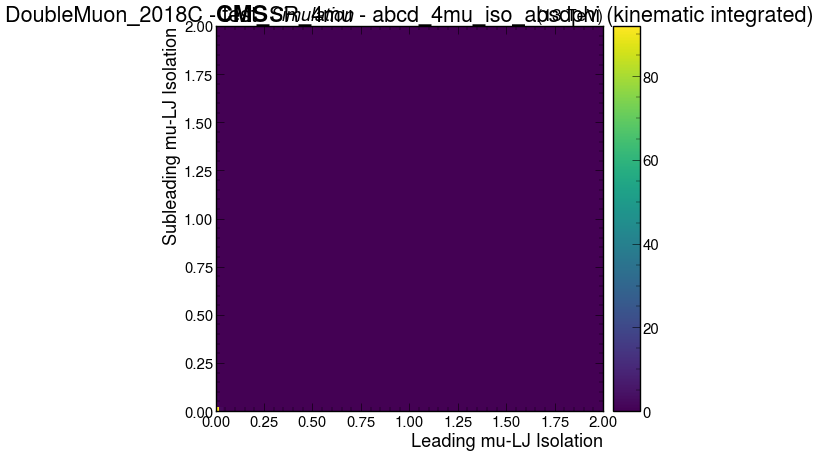

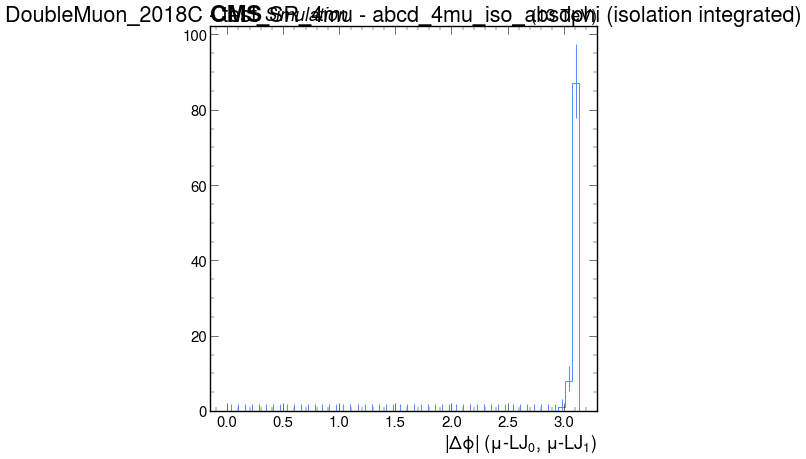

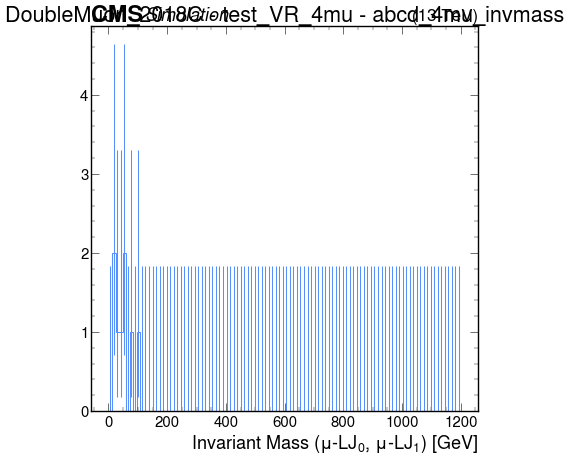

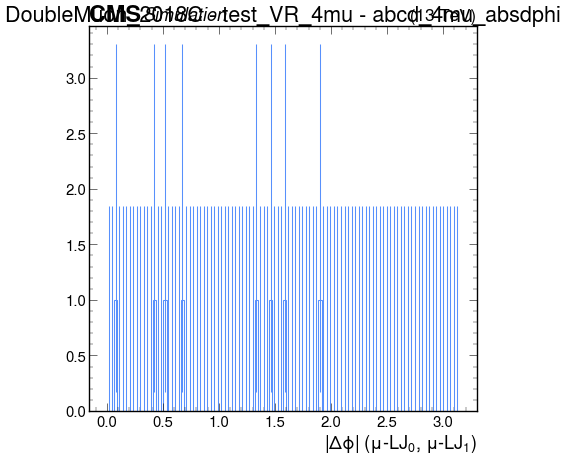

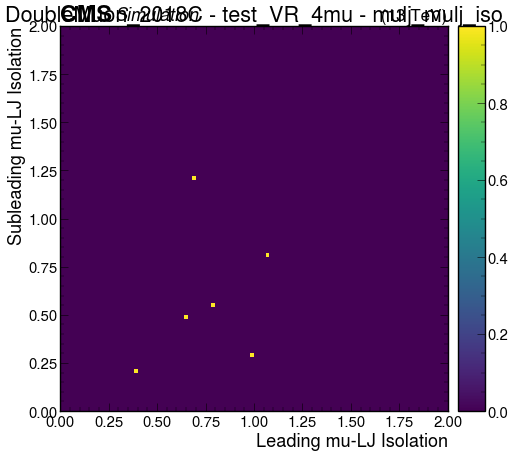

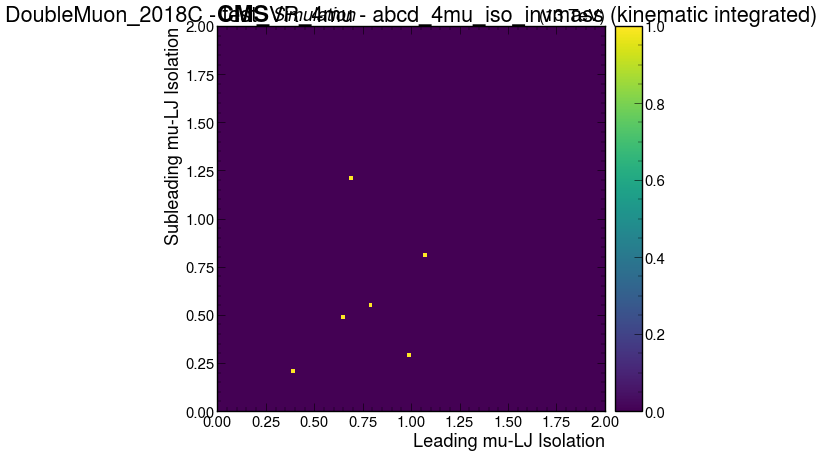

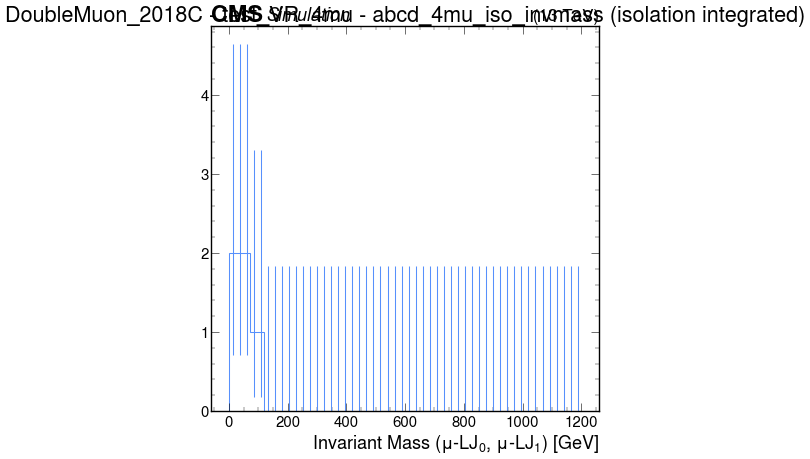

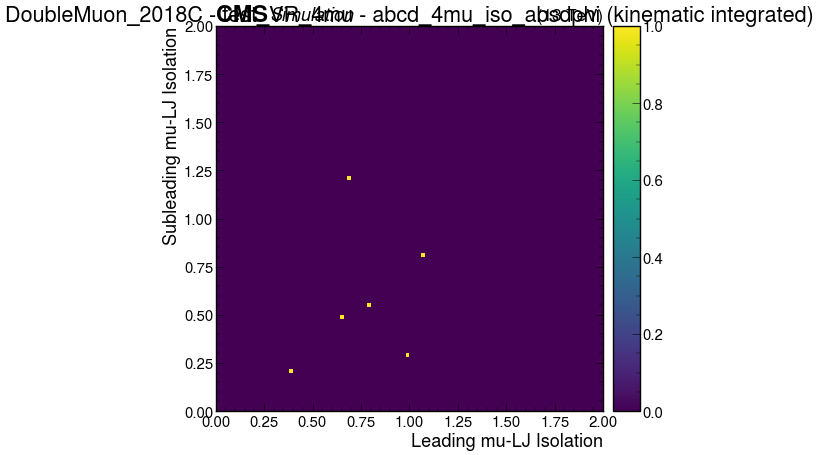

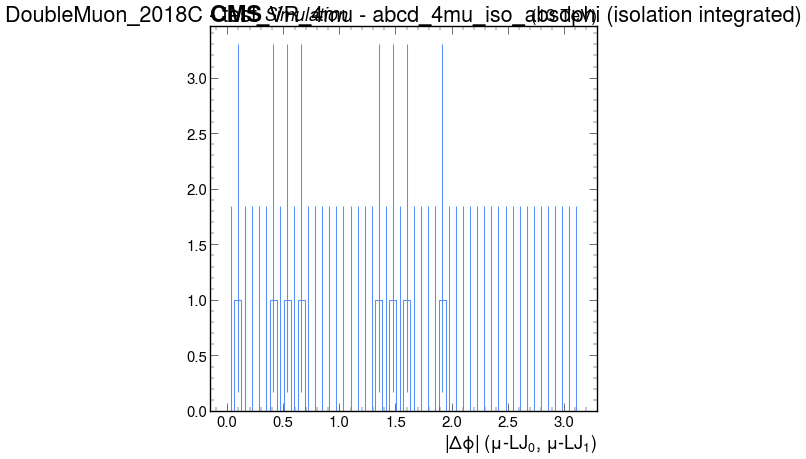

In [6]:
for channel in channels:
    topology = "2mu2e" if channel.endswith("2mu2e") else "4mu"
    relevant_1d_histograms = [name for name in cut_1d_histogram_names if topology in name]
    relevant_2d_histograms = ["mulj_egmlj_iso"] if topology == "2mu2e" else ["mulj_mulj_iso"]
    relevant_3d_histograms = [name for name in iso_3d_histogram_names if topology in name]

    for histogram_name in relevant_1d_histograms:
        histogram = sample_hists[histogram_name][{"channel": channel}]
        utilities.plot(histogram, flow="none")
        plt.title(f"{sample} - {channel} - {histogram_name}")
        plt.show()
        plt.close()

    for histogram_name in relevant_2d_histograms:
        histogram = sample_hists[histogram_name][{"channel": channel}]
        utilities.plot(histogram, flow="none")
        plt.title(f"{sample} - {channel} - {histogram_name}")
        plt.show()
        plt.close()

    for histogram_name in relevant_3d_histograms:
        histogram = sample_hists[histogram_name][{"channel": channel}]
        iso_axis_names = [axis.name for axis in histogram.axes[:2]]
        kinematic_axis_name = histogram.axes[2].name

        iso_plane = histogram.project(*iso_axis_names)
        utilities.plot(iso_plane, flow="none")
        plt.title(f"{sample} - {channel} - {histogram_name} (kinematic integrated)")
        plt.show()
        plt.close()

        kinematic_projection = histogram.project(kinematic_axis_name)
        utilities.plot(kinematic_projection, flow="none")
        plt.title(f"{sample} - {channel} - {histogram_name} (isolation integrated)")
        plt.show()
        plt.close()
